#Phase 1 : Dataset Understanding

In [87]:
import pandas as pd
data = pd.read_csv("Superstore.csv",encoding = 'unicode_escape')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [88]:
data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2013-152156,09-11-2013,12-11-2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2013-152156,09-11-2013,12-11-2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2013-138688,13-06-2013,17-06-2013,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2012-108966,11-10-2012,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2012-108966,11-10-2012,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [89]:
data.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [90]:
data.duplicated().sum()

np.int64(0)

#Phase 2 : Python Data Cleaning

In [91]:
data.drop(columns="Row ID",inplace=True)
data['Postal Code'] = data['Postal Code'].astype(str)
data['Order Date'] = pd.to_datetime(data['Order Date'], dayfirst=True)
data['Ship Date'] = pd.to_datetime(data['Ship Date'], dayfirst=True)
data['Shipping Duration'] = (data['Ship Date'] - data['Order Date']).dt.days
data['Order Year'] = data['Order Date'].dt.year
data['Order Month'] = data['Order Date'].dt.month_name()
data['Order Quarter'] = data['Order Date'].dt.quarter

In [92]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Order ID           9994 non-null   object        
 1   Order Date         9994 non-null   datetime64[ns]
 2   Ship Date          9994 non-null   datetime64[ns]
 3   Ship Mode          9994 non-null   object        
 4   Customer ID        9994 non-null   object        
 5   Customer Name      9994 non-null   object        
 6   Segment            9994 non-null   object        
 7   Country            9994 non-null   object        
 8   City               9994 non-null   object        
 9   State              9994 non-null   object        
 10  Postal Code        9994 non-null   object        
 11  Region             9994 non-null   object        
 12  Product ID         9994 non-null   object        
 13  Category           9994 non-null   object        
 14  Sub-Cate

In [93]:
data.duplicated().sum()

np.int64(1)

In [94]:
data[data.duplicated(keep=False)]

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,...,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Duration,Order Year,Order Month,Order Quarter
3405,US-2011-150119,2011-04-23,2011-04-27,Standard Class,LB-16795,Laurel Beltran,Home Office,United States,Columbus,Ohio,...,Chairs,Global Leather Highback Executive Chair with P...,281.372,2,0.3,-12.0588,4,2011,April,2
3406,US-2011-150119,2011-04-23,2011-04-27,Standard Class,LB-16795,Laurel Beltran,Home Office,United States,Columbus,Ohio,...,Chairs,Global Leather Highback Executive Chair with P...,281.372,2,0.3,-12.0588,4,2011,April,2


In [95]:
data.drop_duplicates(inplace=True)


In [96]:
data.duplicated().sum()

np.int64(0)

In [98]:
data.to_csv('cleaned_superstore.csv', index=False,encoding='utf-8')

#Phase 3 : Python Exploratory Data Analysis (EDA) & Visual EDA

##Phase 3.1 : Numerical EDA Findings

In [99]:
data = pd.read_csv('cleaned_superstore.csv')


In [100]:
data[['Sales','Profit','Quantity','Discount','Shipping Duration']].describe()

,Sales,Profit,Quantity,Discount,Shipping Duration
count,9993.000000,9993.000000,9993.000000,9993.000000,9993.000000
mean,229.852846,28.660971,3.789753,0.156188,3.958871
std,623.276074,234.271476,2.225149,0.206457,1.747184
min,0.444000,-6599.978000,1.000000,0.000000,0.000000
25%,17.280000,1.731000,2.000000,0.000000,3.000000
50%,54.480000,8.671000,3.000000,0.200000,4.000000
75%,209.940000,29.364000,5.000000,0.200000,5.000000
max,22638.480000,8399.976000,14.000000,0.800000,7.000000


In [101]:
data[['Sales','Profit','Quantity','Discount','Shipping Duration']].skew()

,0
Sales,12.972142
Profit,7.561036
Quantity,1.278416
Discount,1.684508
Shipping Duration,-0.422295


##Phase 3.2 : HISTOGRAM ANALYSIS

In [102]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
num_cols = ['Sales', 'Profit', 'Quantity', 'Discount', 'Shipping Duration']

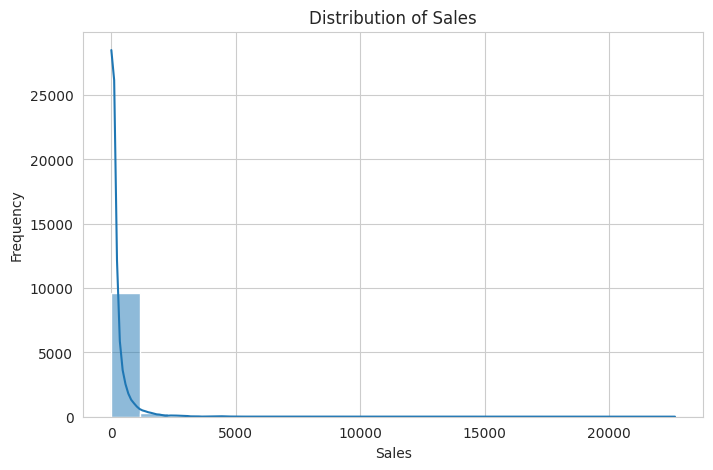

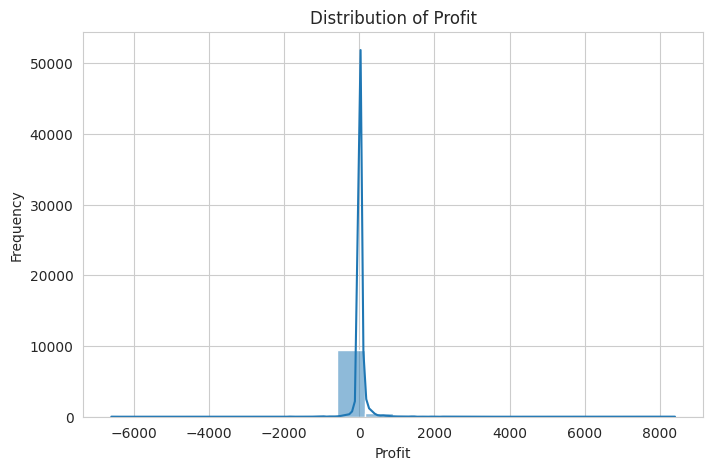

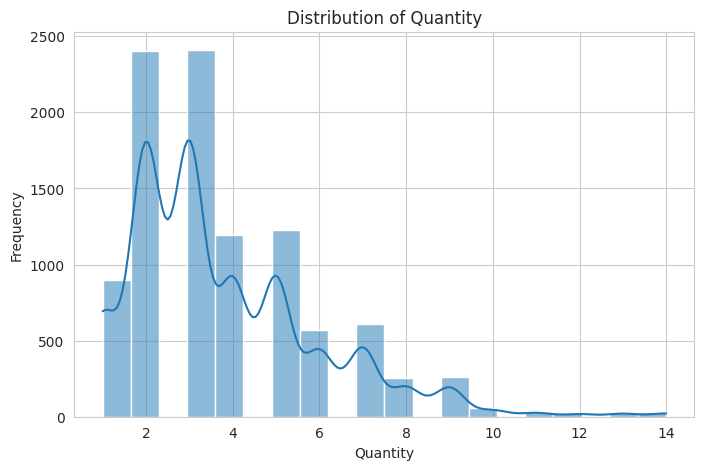

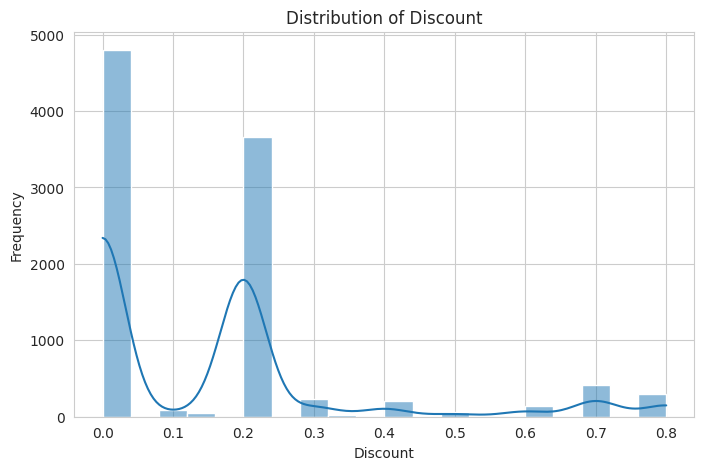

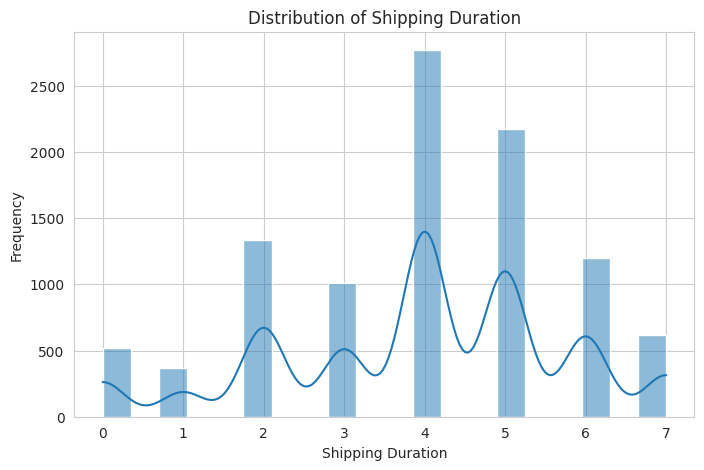

In [103]:
for i in num_cols:
  plt.figure(figsize=(8,5))
  sns.histplot(data[i],bins=20,kde=True)
  plt.title(f'Distribution of {i}')
  plt.xlabel(i)
  plt.ylabel('Frequency')
  plt.show()

##Phase 3.3 : OUTLIER ANALYSIS Using BoxenPlot

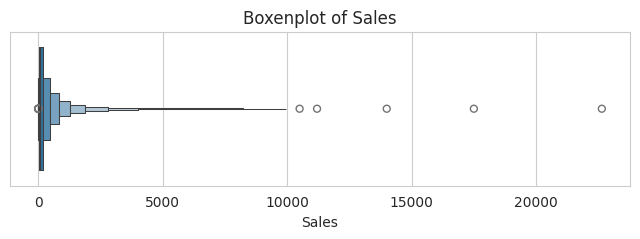

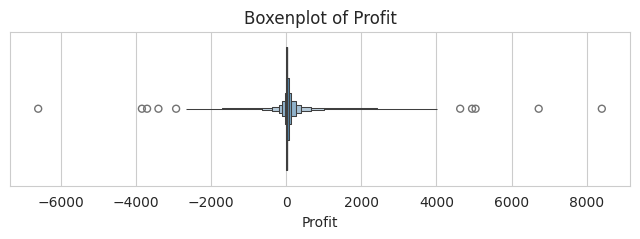

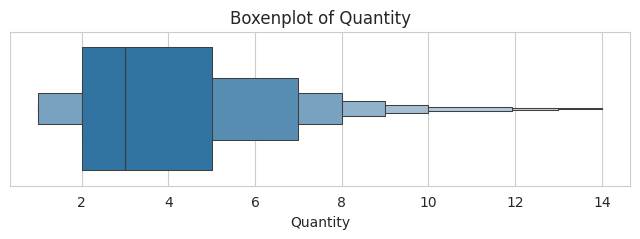

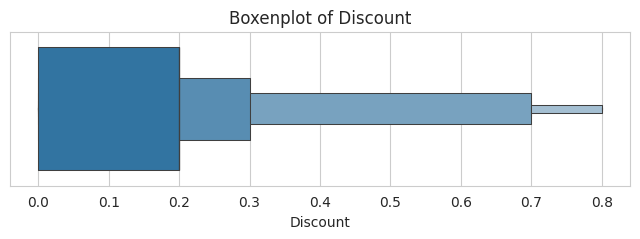

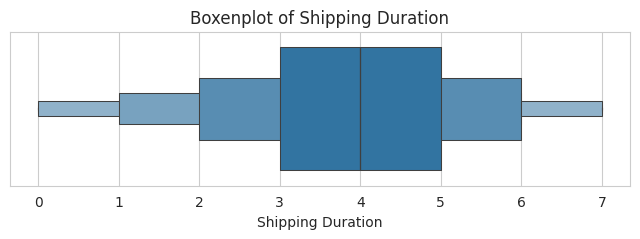

In [104]:
for i in num_cols:
  plt.figure(figsize=(8,2))
  sns.boxenplot(x=data[i])
  plt.title(f'Boxenplot of {i}')
  plt.show()

##Phase 3.4 : Categorical EDA (REGION ANALYSIS)

Region
West       3203
East       2847
Central    2323
South      1620
Name: count, dtype: int64


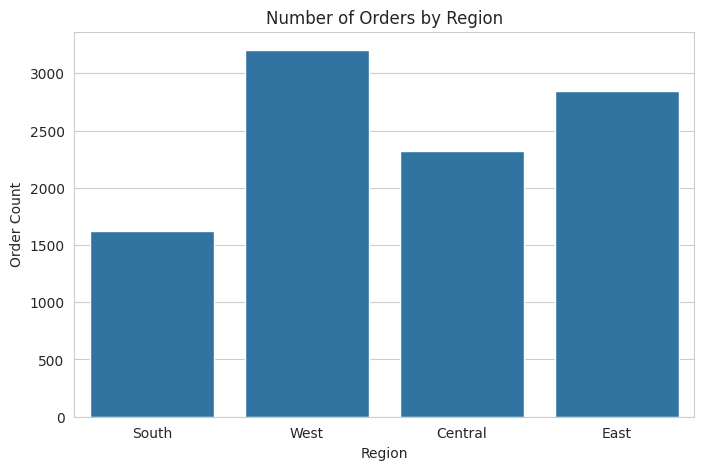

In [105]:
region_orders = data['Region'].value_counts()

print(region_orders)

plt.figure(figsize=(8,5))
sns.countplot(x='Region', data=data)

plt.title('Number of Orders by Region')
plt.xlabel('Region')
plt.ylabel('Order Count')

plt.show()

Region
West       725457.8245
East       678499.8680
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64


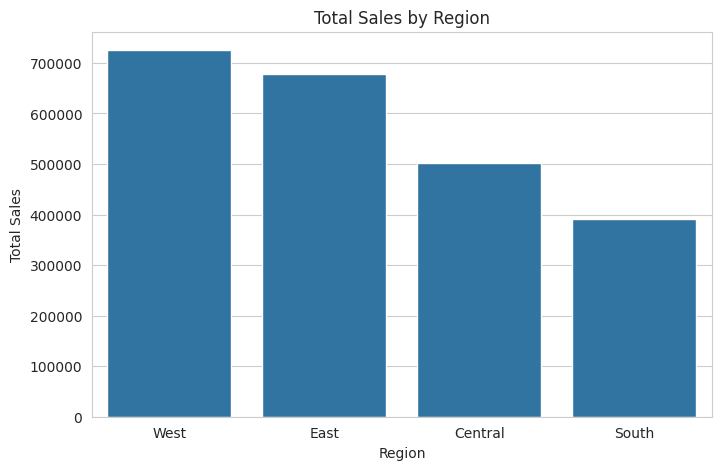

In [106]:
region_sales = data.groupby('Region')['Sales'].sum().sort_values(ascending=False)

print(region_sales)

plt.figure(figsize=(8,5))
sns.barplot(x=region_sales.index,y=region_sales.values)

plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')

plt.show()

Region
West       108418.4489
East        91534.8388
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64


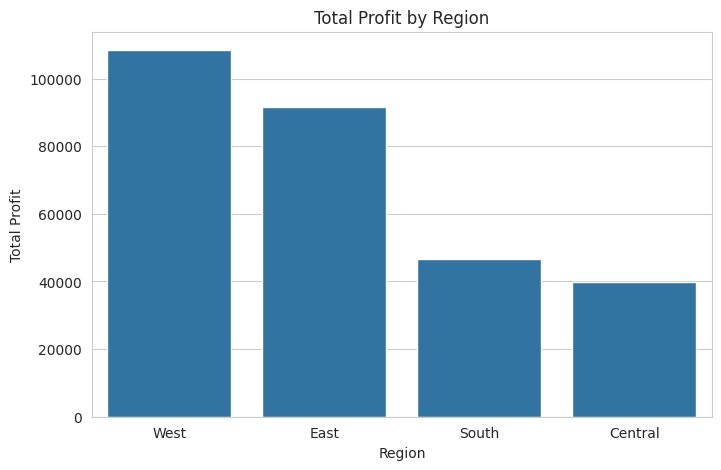

In [107]:
region_profit = data.groupby('Region')['Profit'].sum().sort_values(ascending=False)

print(region_profit)

plt.figure(figsize=(8,5))
sns.barplot(x=region_profit.index,y=region_profit.values)

plt.title('Total Profit by Region')
plt.xlabel('Region')
plt.ylabel('Total Profit')

plt.show()

##Phase 3.5 : SEGMENT ANALYSIS

Segment
Consumer       5191
Corporate      3020
Home Office    1782
Name: count, dtype: int64


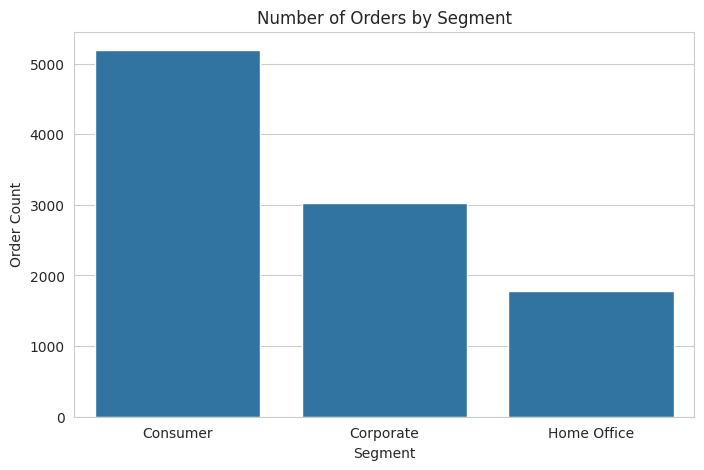

In [108]:
segment_orders = data['Segment'].value_counts()

print(segment_orders)

plt.figure(figsize=(8,5))
sns.countplot(x='Segment', data=data,order=segment_orders.index)

plt.title('Number of Orders by Segment')
plt.xlabel('Segment')
plt.ylabel('Order Count')

plt.show()

Segment
Consumer       1.161401e+06
Corporate      7.061464e+05
Home Office    4.293718e+05
Name: Sales, dtype: float64


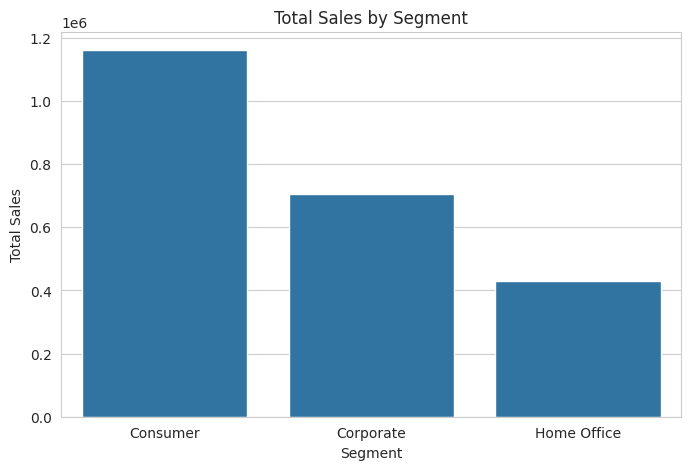

In [109]:
segment_sales = (data.groupby('Segment')['Sales'].sum().sort_values(ascending=False))

print(segment_sales)

plt.figure(figsize=(8,5))
sns.barplot(x=segment_sales.index,y=segment_sales.values)

plt.title('Total Sales by Segment')
plt.xlabel('Segment')
plt.ylabel('Total Sales')

plt.show()

Segment
Consumer       134119.2092
Corporate       91979.1340
Home Office     60310.7373
Name: Profit, dtype: float64


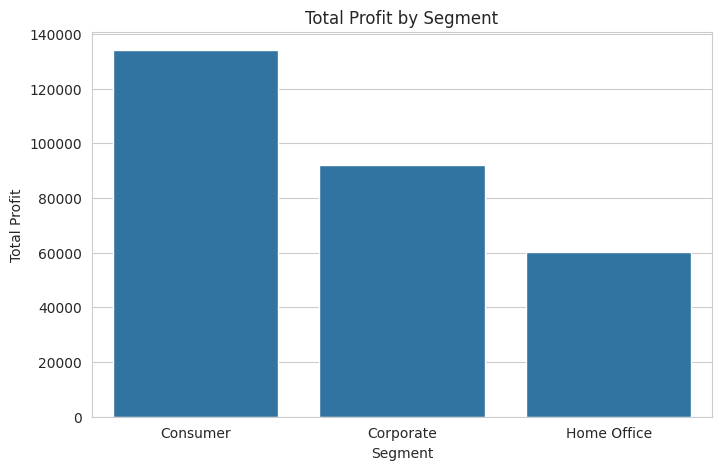

In [110]:
segment_profit = (data.groupby('Segment')['Profit'].sum().sort_values(ascending=False))

print(segment_profit)

plt.figure(figsize=(8,5))
sns.barplot(x=segment_profit.index,y=segment_profit.values)

plt.title('Total Profit by Segment')
plt.xlabel('Segment')
plt.ylabel('Total Profit')

plt.show()

In [111]:
segment_margin = (data.groupby('Segment').agg({'Sales': 'sum','Profit': 'sum'}))

segment_margin['Profit Margin (%)'] = (segment_margin['Profit']/segment_margin['Sales']) * 100

print(segment_margin)

                    Sales       Profit  Profit Margin (%)
Segment                                                  
Consumer     1.161401e+06  134119.2092          11.548050
Corporate    7.061464e+05   91979.1340          13.025506
Home Office  4.293718e+05   60310.7373          14.046274


##Phase 3.6 : Category & Sub-Category Analysis

Category
Technology         836154.0330
Furniture          741718.4233
Office Supplies    719047.0320
Name: Sales, dtype: float64


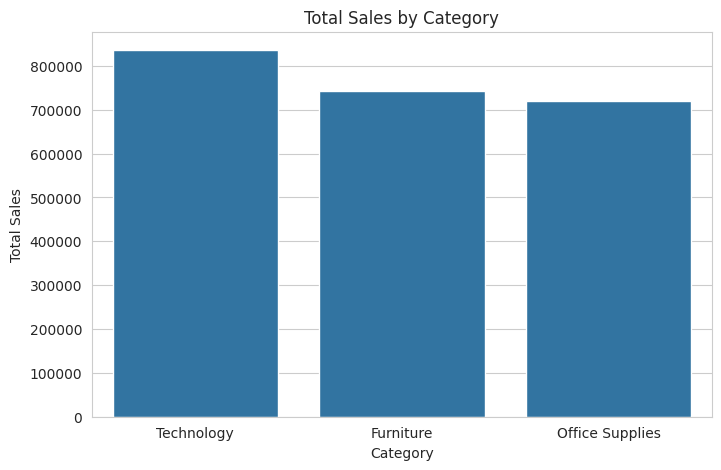

In [112]:
category_sales = (data.groupby('Category')['Sales'].sum().sort_values(ascending=False))

print(category_sales)

plt.figure(figsize=(8,5))
sns.barplot(x=category_sales.index,y=category_sales.values)

plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')

plt.show()

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18463.3316
Name: Profit, dtype: float64


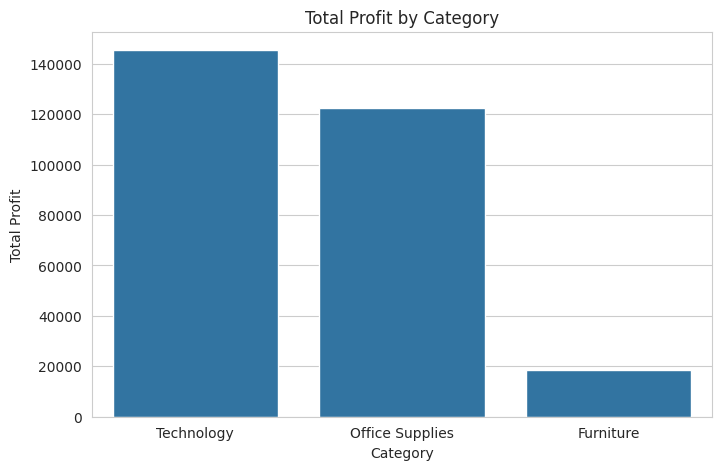

In [113]:
category_profit = data.groupby('Category')['Profit'].sum().sort_values(ascending=False)

print(category_profit)

plt.figure(figsize=(8,5))
sns.barplot(x=category_profit.index, y=category_profit.values)

plt.title('Total Profit by Category')
plt.xlabel('Category')
plt.ylabel('Total Profit')

plt.show()

In [114]:
category_margin = data.groupby('Category').agg({'Sales':'sum','Profit':'sum'})

category_margin['Profit Margin (%)'] = (category_margin['Profit']/category_margin['Sales'])*100

print(category_margin.sort_values('Profit Margin (%)', ascending=False))

                       Sales       Profit  Profit Margin (%)
Category                                                    
Technology       836154.0330  145454.9481          17.395712
Office Supplies  719047.0320  122490.8008          17.035158
Furniture        741718.4233   18463.3316           2.489264


Sub-Category
Phones         330007.0540
Chairs         328167.7310
Storage        223843.6080
Tables         206965.5320
Binders        203412.7330
Machines       189238.6310
Accessories    167380.3180
Copiers        149528.0300
Bookcases      114879.9963
Appliances     107532.1610
Furnishings     91705.1640
Paper           78479.2060
Supplies        46673.5380
Art             27118.7920
Envelopes       16476.4020
Labels          12486.3120
Fasteners        3024.2800
Name: Sales, dtype: float64


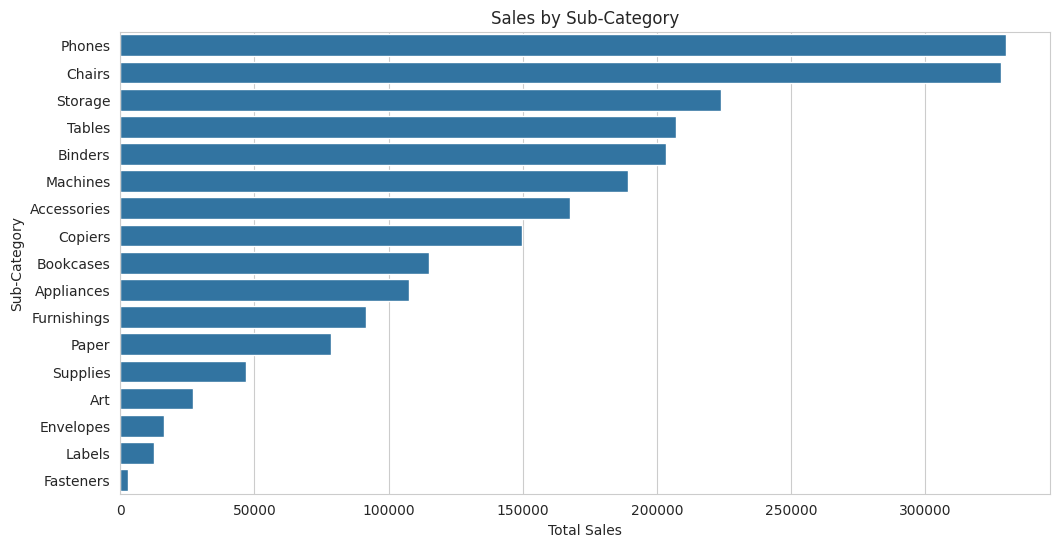

In [115]:
sub_sales = data.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False)

print(sub_sales)

plt.figure(figsize=(12,6))
sns.barplot(x=sub_sales.values, y=sub_sales.index)

plt.title('Sales by Sub-Category')
plt.xlabel('Total Sales')
plt.ylabel('Sub-Category')

plt.show()

Sub-Category
Copiers        55617.8249
Phones         44515.7306
Accessories    41936.6357
Paper          34053.5693
Binders        30221.7633
Chairs         26602.2251
Storage        21278.8264
Appliances     18138.0054
Furnishings    13059.1436
Envelopes       6964.1767
Art             6527.7870
Labels          5546.2540
Machines        3384.7569
Fasteners        949.5182
Supplies       -1189.0995
Bookcases      -3472.5560
Tables        -17725.4811
Name: Profit, dtype: float64


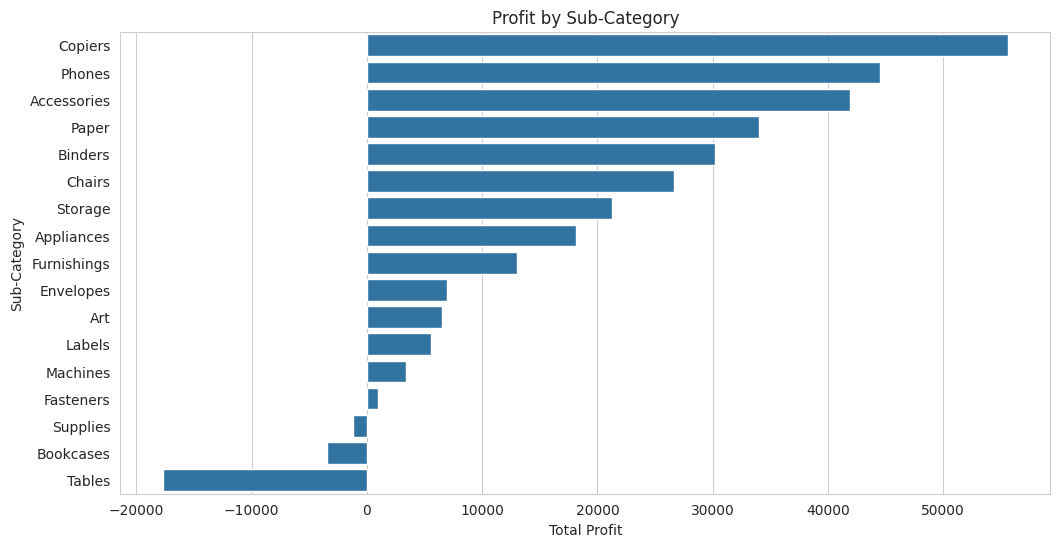

In [116]:
sub_profit = data.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False)

print(sub_profit)

plt.figure(figsize=(12,6))
sns.barplot(x=sub_profit.values, y=sub_profit.index)

plt.title('Profit by Sub-Category')
plt.xlabel('Total Profit')
plt.ylabel('Sub-Category')

plt.show()

##Phase 3.7 : Discount Analysis

In [117]:
discount_profit_corr = data[['Discount','Profit']].corr()

print(discount_profit_corr)

          Discount    Profit
Discount  1.000000 -0.219481
Profit   -0.219481  1.000000


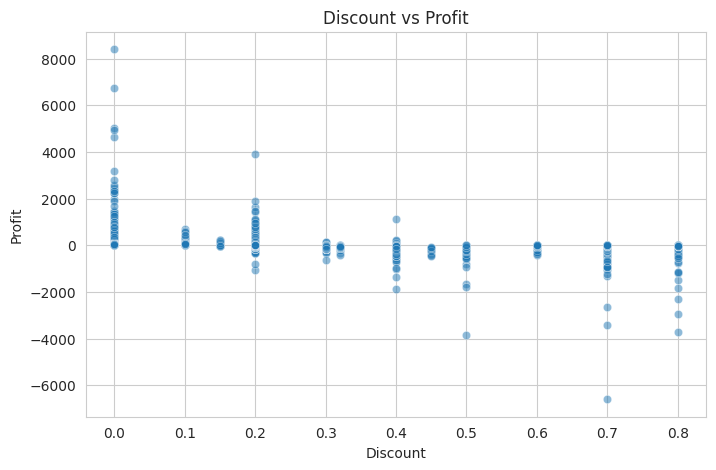

In [118]:
plt.figure(figsize=(8,5))

sns.scatterplot(x=data['Discount'], y=data['Profit'], alpha=0.5)

plt.title('Discount vs Profit')
plt.xlabel('Discount')
plt.ylabel('Profit')

plt.show()

Discount
0.10     96.055074
0.00     66.900292
0.15     27.288298
0.20     24.702572
0.60    -43.077212
0.30    -45.828401
0.32    -88.560656
0.70    -95.874060
0.80   -101.796797
0.40   -111.927429
0.45   -226.646464
0.50   -310.703456
Name: Profit, dtype: float64


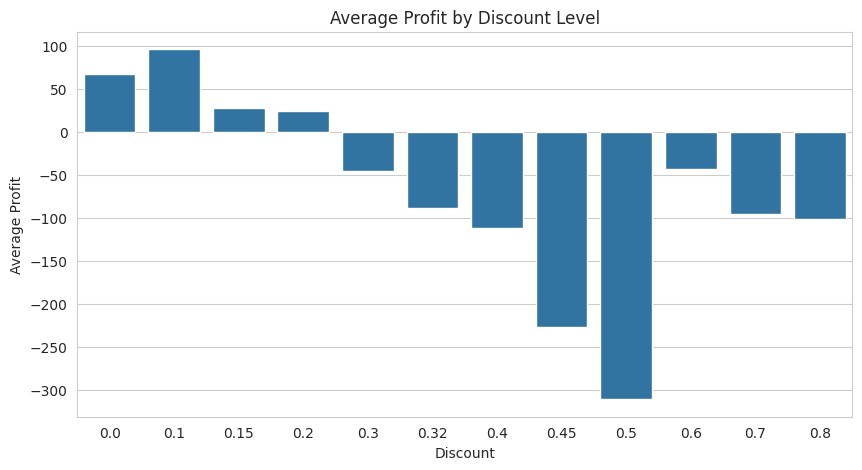

In [119]:
discount_profit = data.groupby('Discount')['Profit'].mean().sort_values(ascending=False)

print(discount_profit)

plt.figure(figsize=(10,5))

sns.barplot(x=discount_profit.index, y=discount_profit.values)

plt.title('Average Profit by Discount Level')
plt.xlabel('Discount')
plt.ylabel('Average Profit')

plt.show()

Discount
0.00    226.742074
0.10    578.397351
0.15    529.971567
0.20    209.076940
0.30    455.510102
0.32    536.794770
0.40    565.134874
0.45    498.634000
0.50    892.705152
0.60     48.150000
0.70     97.177708
0.80     56.545853
Name: Sales, dtype: float64


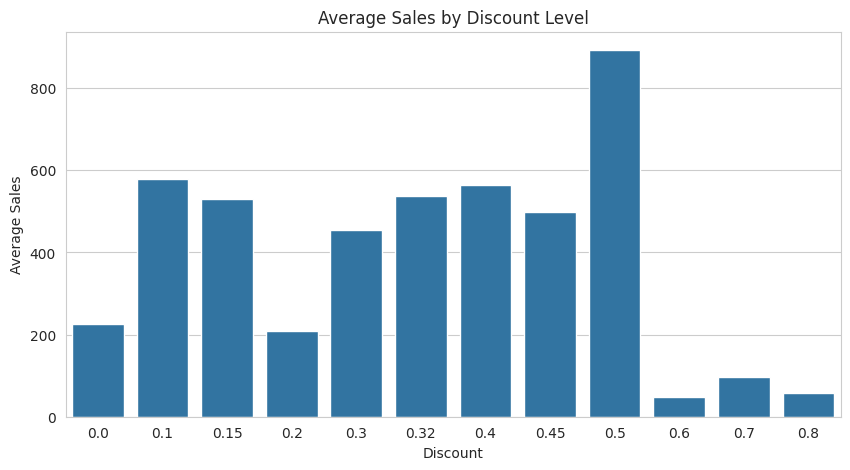

In [120]:
discount_sales = data.groupby('Discount')['Sales'].mean()

print(discount_sales)

plt.figure(figsize=(10,5))

sns.barplot(x=discount_sales.index, y=discount_sales.values)

plt.title('Average Sales by Discount Level')
plt.xlabel('Discount')
plt.ylabel('Average Sales')

plt.show()

##Phase 3.8 : Customer Analysis

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64


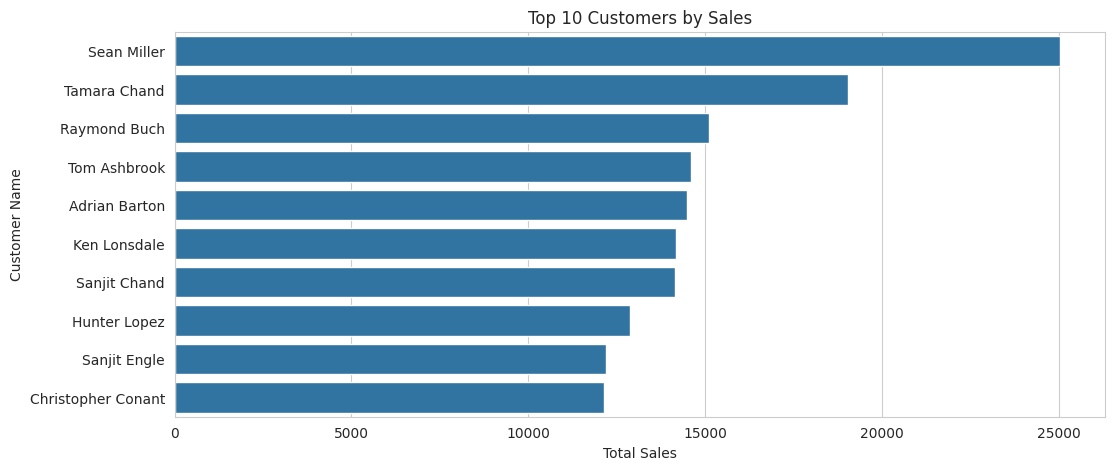

In [121]:
top_sales_customers = data.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(10)

print(top_sales_customers)

plt.figure(figsize=(12,5))
sns.barplot(x=top_sales_customers.values, y=top_sales_customers.index)

plt.title('Top 10 Customers by Sales')
plt.xlabel('Total Sales')
plt.ylabel('Customer Name')

plt.show()

Customer Name
Cindy Stewart      -6626.3895
Grant Thornton     -4108.6589
Luke Foster        -3583.9770
Sharelle Roach     -3333.9144
Henry Goldwyn      -2797.9635
Nathan Cano        -2204.8072
Sean Braxton       -2082.7451
Sean Miller        -1980.7393
Christine Phan     -1850.3029
Natalie Fritzler   -1695.9714
Name: Profit, dtype: float64


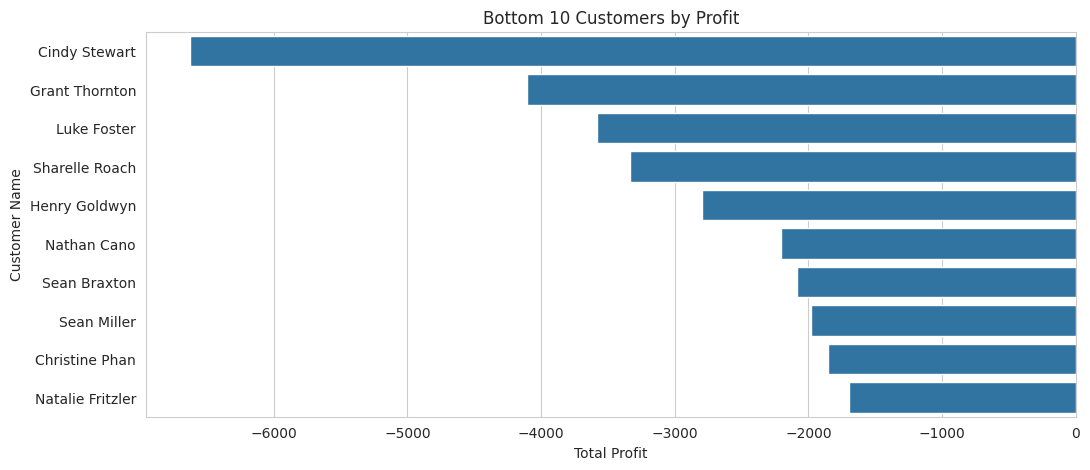

In [122]:
bottom_profit_customers = data.groupby('Customer Name')['Profit'].sum().sort_values().head(10)

print(bottom_profit_customers)

plt.figure(figsize=(12,5))
sns.barplot(x=bottom_profit_customers.values, y=bottom_profit_customers.index)

plt.title('Bottom 10 Customers by Profit')
plt.xlabel('Total Profit')
plt.ylabel('Customer Name')

plt.show()

Customer Name
Cindy Stewart      -6626.3895
Grant Thornton     -4108.6589
Luke Foster        -3583.9770
Sharelle Roach     -3333.9144
Henry Goldwyn      -2797.9635
Nathan Cano        -2204.8072
Sean Braxton       -2082.7451
Sean Miller        -1980.7393
Christine Phan     -1850.3029
Natalie Fritzler   -1695.9714
Name: Profit, dtype: float64


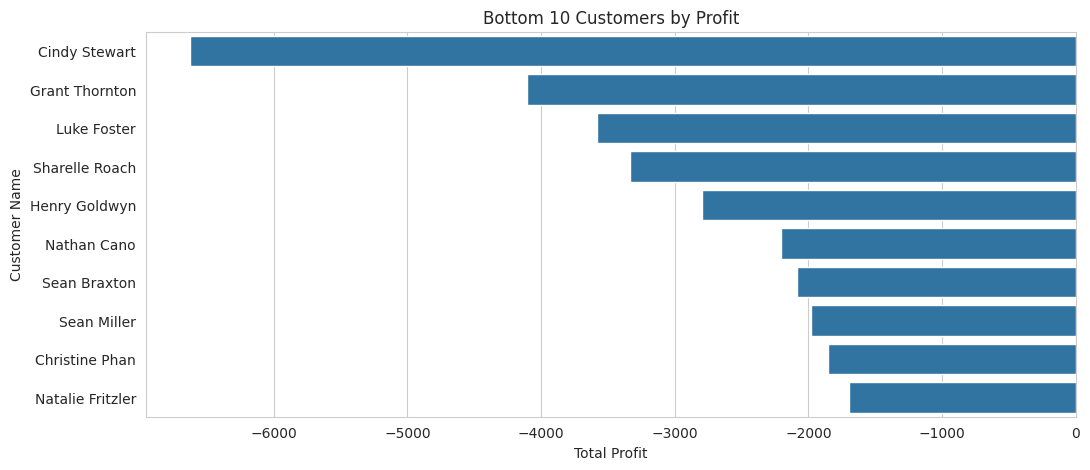

In [123]:
bottom_profit_customers = data.groupby('Customer Name')['Profit'].sum().sort_values().head(10)

print(bottom_profit_customers)

plt.figure(figsize=(12,5))
sns.barplot(x=bottom_profit_customers.values, y=bottom_profit_customers.index)

plt.title('Bottom 10 Customers by Profit')
plt.xlabel('Total Profit')
plt.ylabel('Customer Name')

plt.show()

In [124]:
customer_margin = data.groupby('Customer Name').agg({'Sales':'sum','Profit':'sum'})

customer_margin['Profit Margin (%)'] = (customer_margin['Profit']/customer_margin['Sales'])*100

print(customer_margin.sort_values('Profit Margin (%)', ascending=False).head(10))

                          Sales     Profit  Profit Margin (%)
Customer Name                                                
Jenna Caffey           1058.108   502.9244          47.530536
Tamara Chand          19052.218  8981.3239          47.140569
Raymond Buch          15117.339  6976.0959          46.146322
Steven Roelle          4345.886  1990.4244          45.800198
Bobby Odegard           130.830    59.4522          45.442330
Hunter Lopez          12873.298  5622.4292          43.675127
Andy Reiter            6608.448  2884.6208          43.650503
Christopher Martinez   8954.020  3899.8904          43.554631
Ivan Gibson             744.574   320.4982          43.044506
Roy Skaria               22.328     9.5838          42.922788


##Phase 3.9 : Product Analysis

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


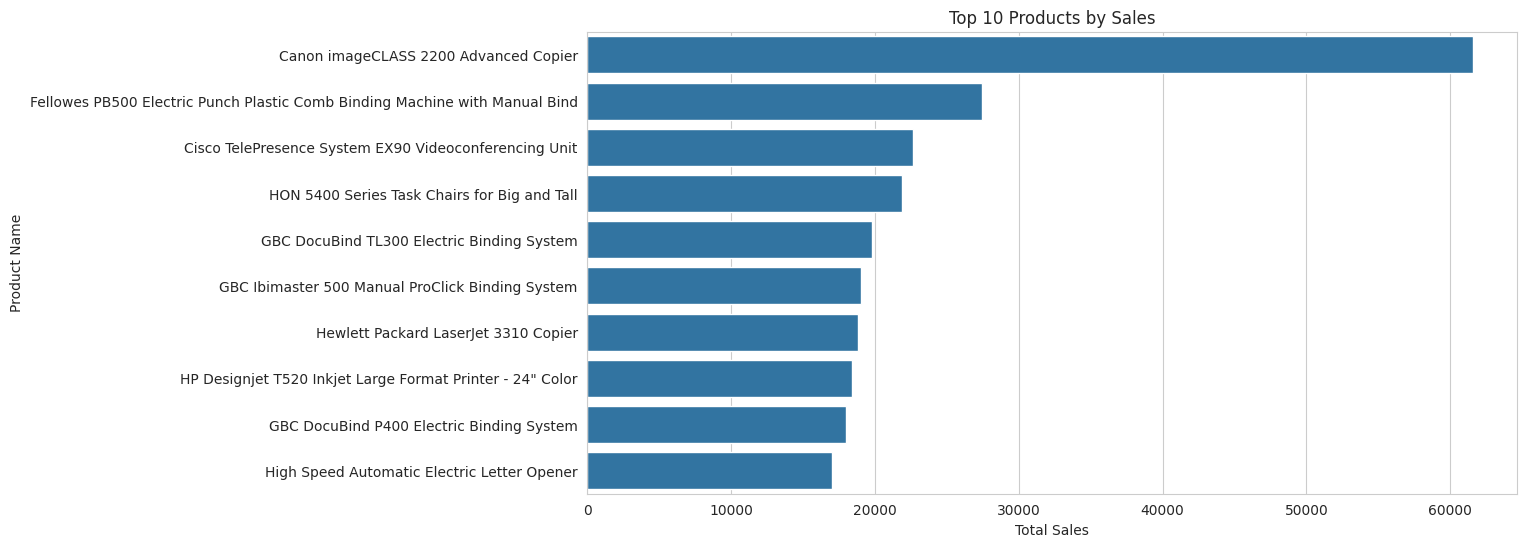

In [125]:
top_sales_products = data.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

print(top_sales_products)

plt.figure(figsize=(12,6))
sns.barplot(x=top_sales_products.values, y=top_sales_products.index)

plt.title('Top 10 Products by Sales')
plt.xlabel('Total Sales')
plt.ylabel('Product Name')

plt.show()

Product Name
Canon imageCLASS 2200 Advanced Copier                                          25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind     7753.0390
Hewlett Packard LaserJet 3310 Copier                                            6983.8836
Canon PC1060 Personal Laser Copier                                              4570.9347
HP Designjet T520 Inkjet Large Format Printer - 24" Color                       4094.9766
Ativa V4110MDD Micro-Cut Shredder                                               3772.9461
3D Systems Cube Printer, 2nd Generation, Magenta                                3717.9714
Plantronics Savi W720 Multi-Device Wireless Headset System                      3696.2820
Ibico EPK-21 Electric Binding System                                            3345.2823
Zebra ZM400 Thermal Label Printer                                               3343.5360
Name: Profit, dtype: float64


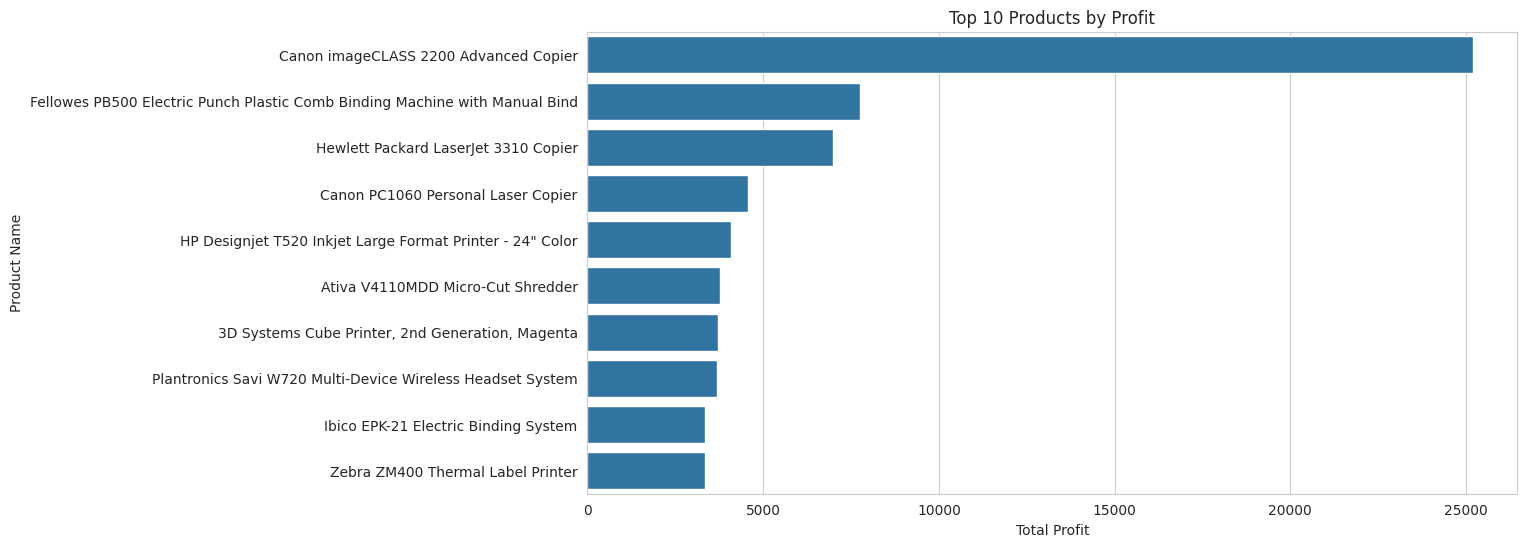

In [126]:
top_profit_products = data.groupby('Product Name')['Profit'].sum().sort_values(ascending=False).head(10)

print(top_profit_products)

plt.figure(figsize=(12,6))
sns.barplot(x=top_profit_products.values, y=top_profit_products.index)

plt.title('Top 10 Products by Profit')
plt.xlabel('Total Profit')
plt.ylabel('Product Name')

plt.show()

Product Name
Cubify CubeX 3D Printer Double Head Print                           -8879.9704
Lexmark MX611dhe Monochrome Laser Printer                           -4589.9730
Cubify CubeX 3D Printer Triple Head Print                           -3839.9904
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases            -2876.1156
Bush Advantage Collection Racetrack Conference Table                -1934.3976
GBC DocuBind P400 Electric Binding System                           -1878.1662
Cisco TelePresence System EX90 Videoconferencing Unit               -1811.0784
Martin Yale Chadless Opener Electric Letter Opener                  -1299.1836
Balt Solid Wood Round Tables                                        -1201.0581
BoxOffice By Design Rectangular and Half-Moon Meeting Room Tables   -1148.4375
Name: Profit, dtype: float64


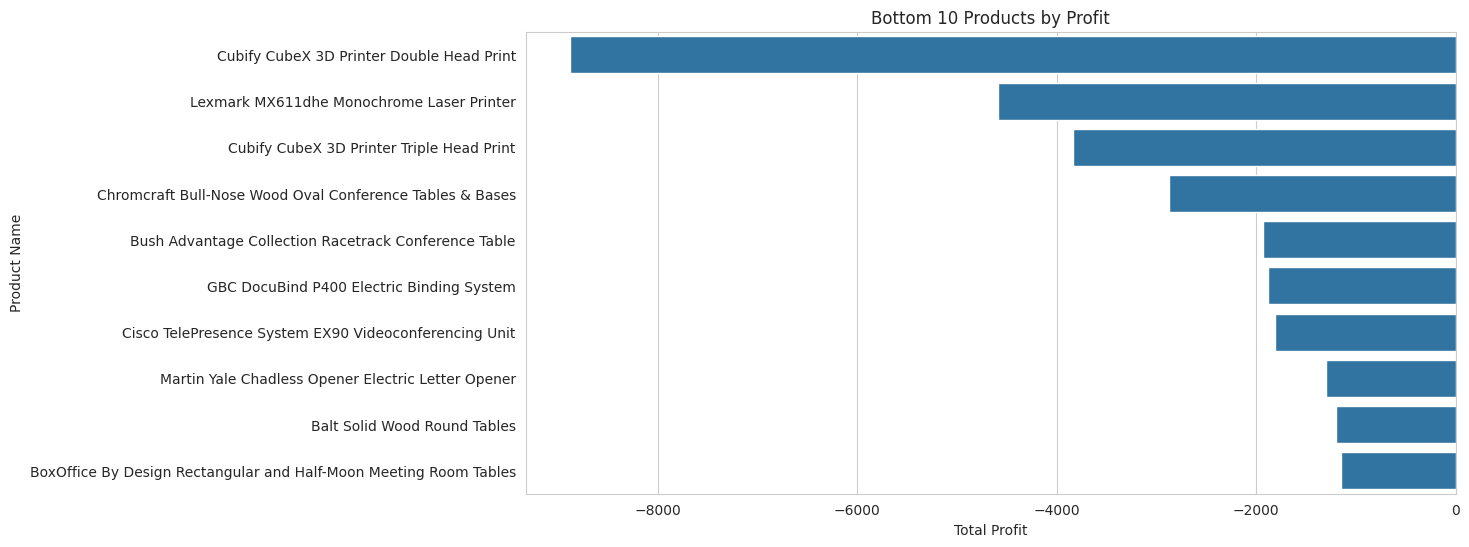

In [127]:
bottom_profit_products = data.groupby('Product Name')['Profit'].sum().sort_values().head(10)

print(bottom_profit_products)

plt.figure(figsize=(12,6))
sns.barplot(x=bottom_profit_products.values, y=bottom_profit_products.index)

plt.title('Bottom 10 Products by Profit')
plt.xlabel('Total Profit')
plt.ylabel('Product Name')

plt.show()

In [128]:
product_margin = data.groupby('Product Name').agg({'Sales':'sum','Profit':'sum'})

product_margin['Profit Margin (%)'] = (product_margin['Profit']/product_margin['Sales'])*100

print(product_margin.sort_values('Profit Margin (%)', ascending=False).head(10))

                                                      Sales     Profit  \
Product Name                                                             
Adams Telephone Message Book w/Frequently-Calle...   223.44   111.7200   
Avery 475                                            266.40   133.2000   
Southworth Structures Collection                      72.80    36.4000   
Tops Green Bar Computer Printout Paper               342.58   171.2900   
Canon imageCLASS MF7460 Monochrome Digital Lase...  3991.98  1995.9900   
Xerox 1890                                           244.70   122.3500   
Xerox 1918                                           155.04    75.9696   
Avery 5                                                5.76     2.8224   
Ativa V4110MDD Micro-Cut Shredder                   7699.89  3772.9461   
Avery 478                                             88.38    43.3062   

                                                    Profit Margin (%)  
Product Name                           

##Phase 3.10 : Time Series Analysis

In [129]:
print(data[['Order Date','Ship Date']].dtypes)

Order Date    object
Ship Date     object
dtype: object


In [130]:
data['Order Date'] = pd.to_datetime(data['Order Date'], format='%Y-%m-%d')
data['Ship Date'] = pd.to_datetime(data['Ship Date'], format='%Y-%m-%d')

In [131]:
print(data[['Order Date','Ship Date']].dtypes)

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object


Order Date
2011-01     13946.2290
2011-02      4810.5580
2011-03     55691.0090
2011-04     28013.9730
2011-05     23648.2870
2011-06     34595.1276
2011-07     33946.3930
2011-08     27909.4685
2011-09     81777.3508
2011-10     31453.3930
2011-11     78628.7167
2011-12     69545.6205
2012-01     18174.0756
2012-02     12210.8670
2012-03     38466.7960
2012-04     34195.2085
2012-05     30131.6865
2012-06     24797.2920
2012-07     28765.3250
2012-08     36898.3322
2012-09     64595.9180
2012-10     31404.9235
2012-11     75972.5635
2012-12     74919.5212
2013-01     18542.4910
2013-02     22867.7110
2013-03     51186.2170
2013-04     39248.5930
2013-05     56691.0770
2013-06     39430.4430
2013-07     38440.7550
2013-08     33265.5643
2013-09     72908.1089
2013-10     56463.1300
2013-11     82192.3228
2013-12     97237.4170
2014-01     44703.1420
2014-02     20283.5134
2014-03     53908.9620
2014-04     40112.4209
2014-05     45651.2362
2014-06     48259.7487
2014-07     48428.3650


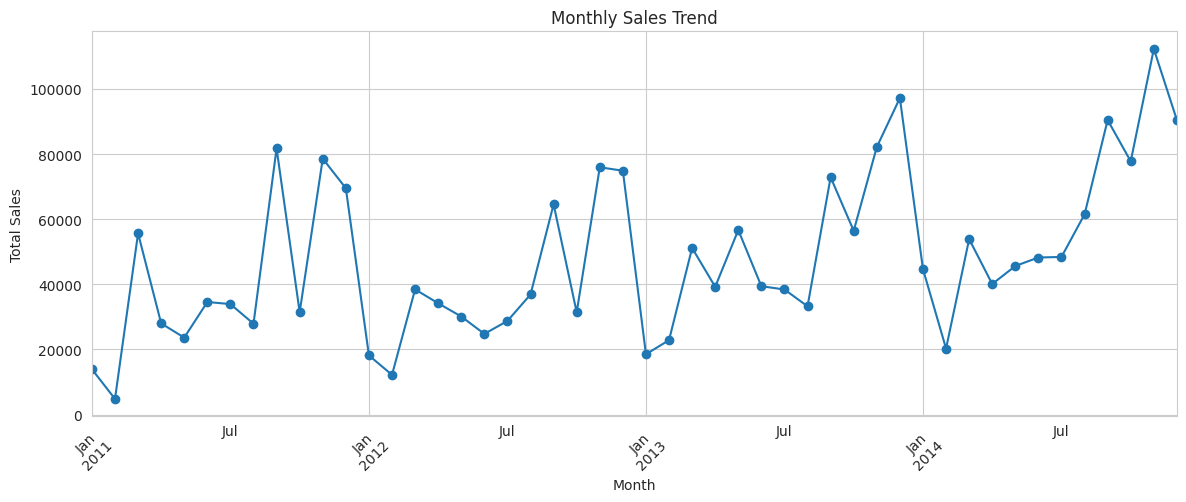

In [132]:
monthly_sales = data.groupby(data['Order Date'].dt.to_period('M'))['Sales'].sum()

print(monthly_sales)

plt.figure(figsize=(14,5))
monthly_sales.plot(marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')

plt.xticks(rotation=45)

plt.show()

Order Date
2011-01     2446.7711
2011-02      865.7280
2011-03      498.7299
2011-04     3500.8940
2011-05     2738.7096
2011-06     4976.5244
2011-07     -841.4826
2011-08     5318.1050
2011-09     8328.0994
2011-10     3448.2573
2011-11     9292.1269
2011-12     8983.5699
2012-01    -3281.0070
2012-02     2821.2762
2012-03     9724.6724
2012-04     4187.4962
2012-05     4667.8690
2012-06     3335.5572
2012-07     3288.6483
2012-08     5355.8084
2012-09     8209.1627
2012-10     2817.3660
2012-11    12474.7884
2012-12     8016.9659
2013-01     2824.8233
2013-02     4996.2467
2013-03     3625.2715
2013-04     2957.8446
2013-05     8627.4764
2013-06     4499.5845
2013-07     4464.6602
2013-08     2328.3534
2013-09     9360.4910
2013-10    15763.3797
2013-11     4376.0694
2013-12    17902.7301
2014-01     7208.6826
2014-02     1605.6478
2014-03    12957.8999
2014-04     2803.6308
2014-05     6274.4578
2014-06     8087.6684
2014-07     6623.5571
2014-08     8894.4486
2014-09    11395.4394

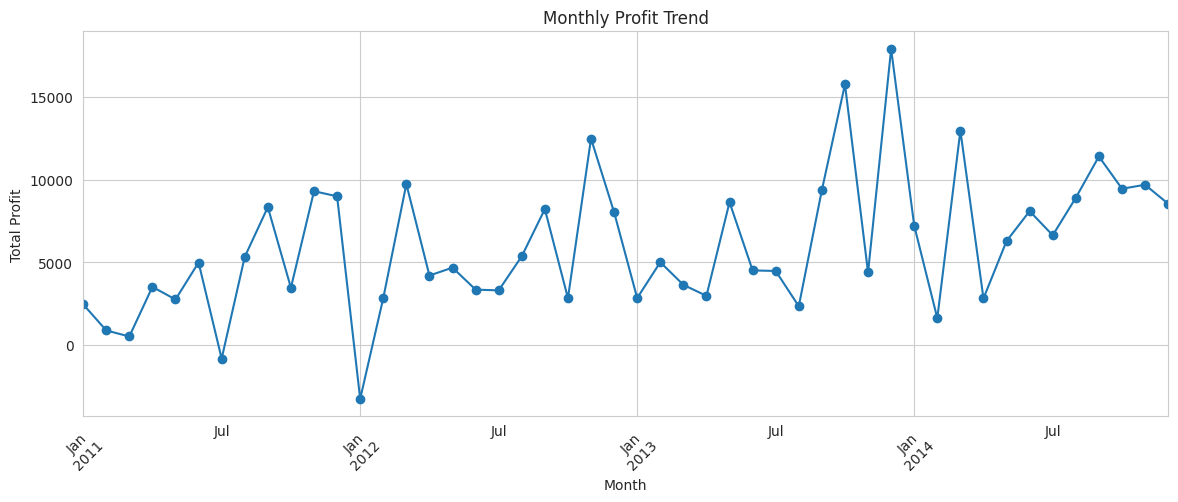

In [133]:
monthly_profit = data.groupby(data['Order Date'].dt.to_period('M'))['Profit'].sum()

print(monthly_profit)

plt.figure(figsize=(14,5))
monthly_profit.plot(marker='o')

plt.title('Monthly Profit Trend')
plt.xlabel('Month')
plt.ylabel('Total Profit')

plt.xticks(rotation=45)

plt.show()

Order Year
2011    483966.1261
2012    470532.5090
2013    608473.8300
2014    733947.0232
Name: Sales, dtype: float64


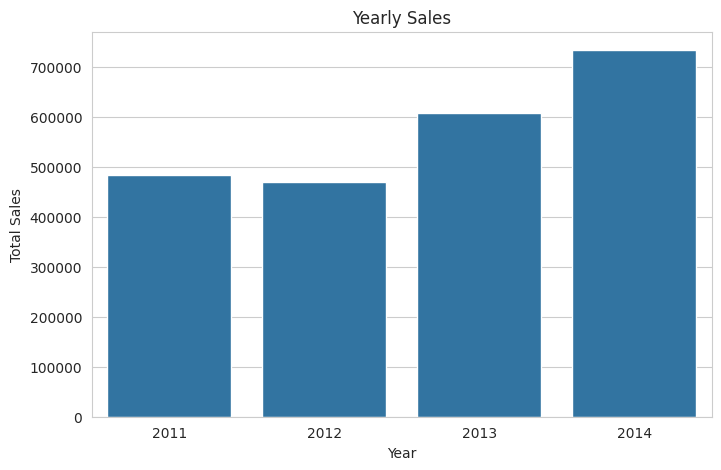

In [134]:
yearly_sales = data.groupby('Order Year')['Sales'].sum()

print(yearly_sales)

plt.figure(figsize=(8,5))
sns.barplot(x=yearly_sales.index, y=yearly_sales.values)

plt.title('Yearly Sales')
plt.xlabel('Year')
plt.ylabel('Total Sales')

plt.show()

Order Year
2011    49556.0329
2012    61618.6037
2013    81726.9308
2014    93507.5131
Name: Profit, dtype: float64


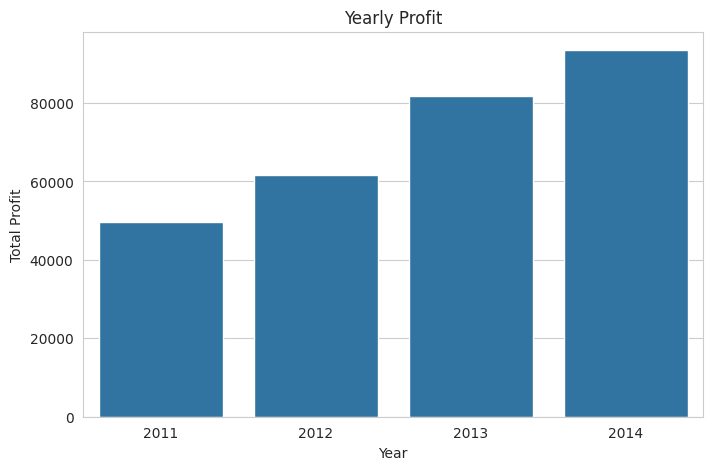

In [135]:
yearly_profit = data.groupby('Order Year')['Profit'].sum()

print(yearly_profit)

plt.figure(figsize=(8,5))
sns.barplot(x=yearly_profit.index, y=yearly_profit.values)

plt.title('Yearly Profit')
plt.xlabel('Year')
plt.ylabel('Total Profit')

plt.show()

Order Month
January       95365.9376
February      60172.6494
March        199252.9840
April        141570.1954
May          156122.2867
June         147082.6113
July         149580.8380
August       159589.4510
September    309770.0997
October      197115.2017
November     349120.0740
December     332177.1595
Name: Sales, dtype: float64


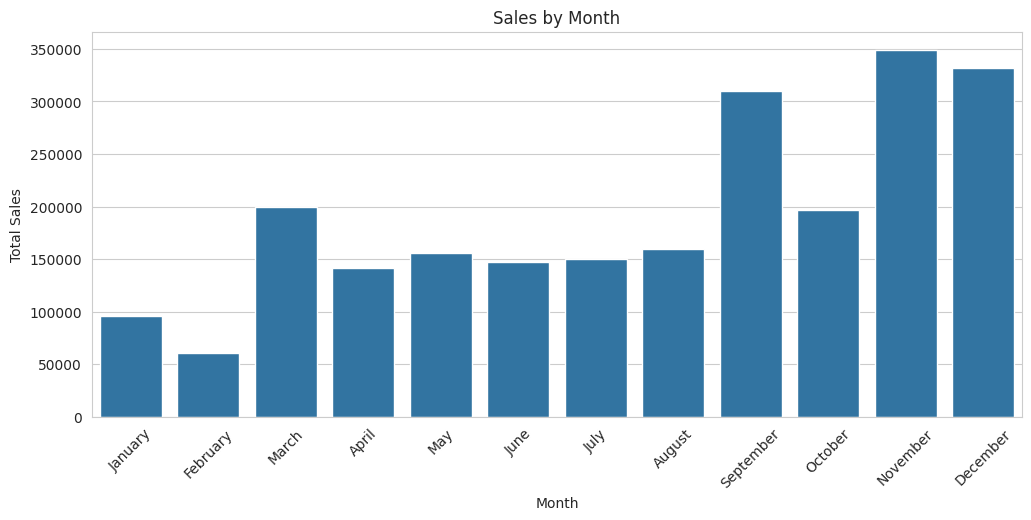

In [136]:
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

month_sales = data.groupby('Order Month')['Sales'].sum().reindex(month_order)

print(month_sales)

plt.figure(figsize=(12,5))
sns.barplot(x=month_sales.index, y=month_sales.values)

plt.title('Sales by Month')
plt.xlabel('Month')
plt.ylabel('Total Sales')

plt.xticks(rotation=45)

plt.show()

Order Quarter
1    354791.5710
2    444775.0934
3    618940.3887
4    878412.4352
Name: Sales, dtype: float64


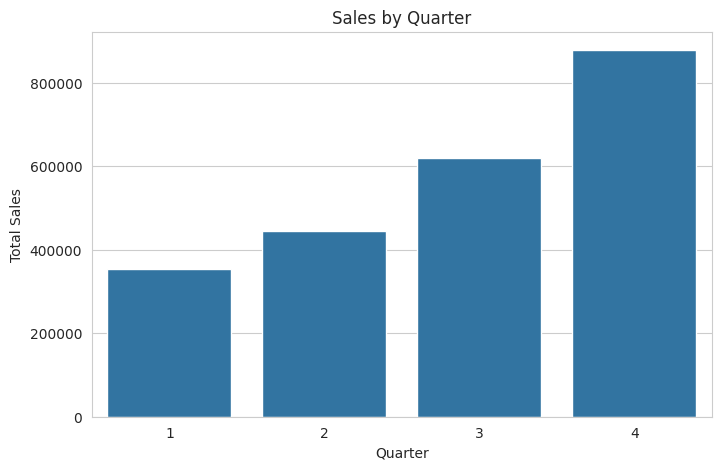

In [137]:
quarter_sales = data.groupby('Order Quarter')['Sales'].sum()

print(quarter_sales)

plt.figure(figsize=(8,5))
sns.barplot(x=quarter_sales.index, y=quarter_sales.values)

plt.title('Sales by Quarter')
plt.xlabel('Quarter')
plt.ylabel('Total Sales')

plt.show()

##Phase 3.11 : Correlation Analysis

In [138]:
corr_matrix = data[['Sales','Profit','Quantity','Discount','Shipping Duration']].corr()

corr_matrix

,Sales,Profit,Quantity,Discount,Shipping Duration
Sales,1.000000,0.479067,0.200808,-0.028197,-0.007329
Profit,0.479067,1.000000,0.066241,-0.219481,-0.004683
Quantity,0.200808,0.066241,1.000000,0.008680,0.018421
Discount,-0.028197,-0.219481,0.008680,1.000000,0.000242
Shipping Duration,-0.007329,-0.004683,0.018421,0.000242,1.000000


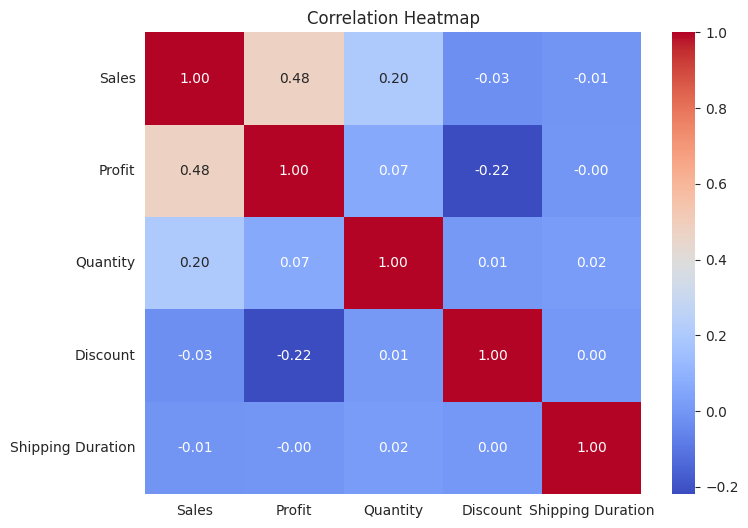

In [139]:
plt.figure(figsize=(8,6))

sns.heatmap(corr_matrix,annot=True,cmap='coolwarm',fmt='.2f')

plt.title('Correlation Heatmap')

plt.show()

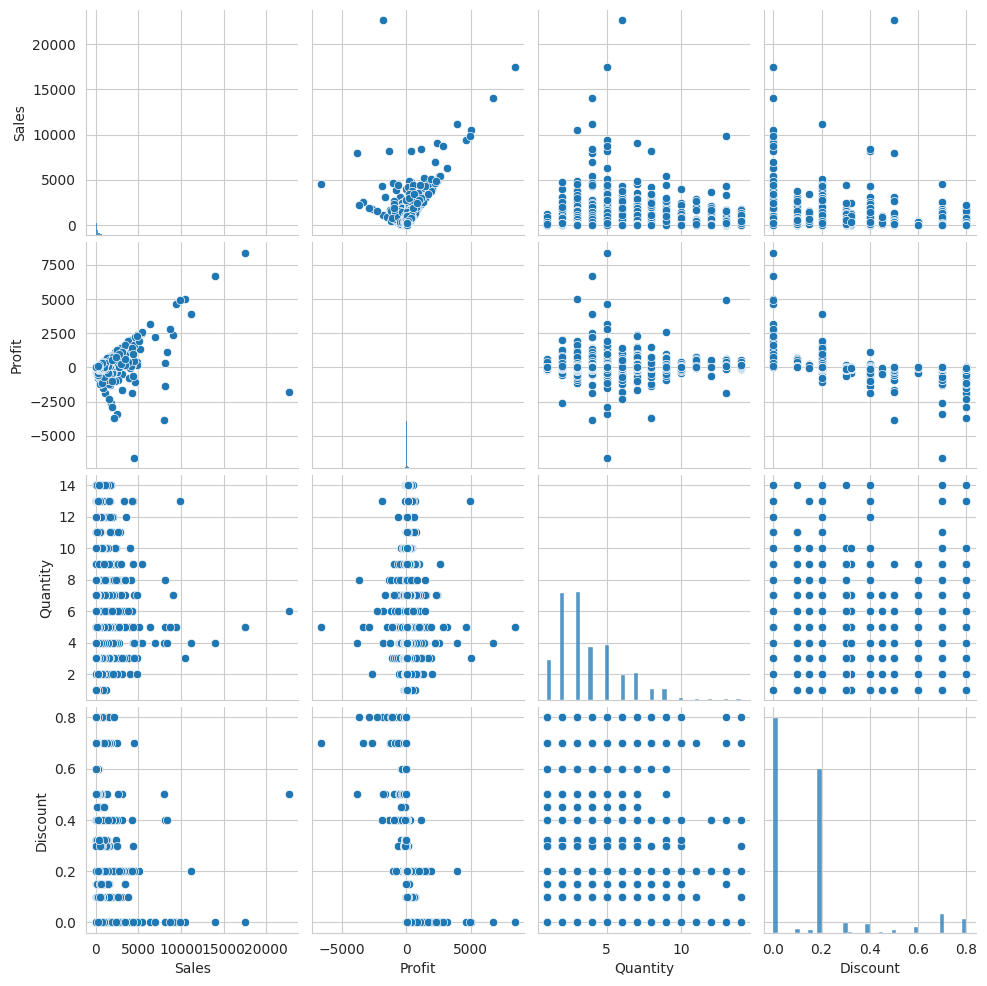

In [140]:
sns.pairplot(data[['Sales','Profit','Quantity','Discount']])

plt.show()

In [141]:
profit_corr = corr_matrix['Profit'].sort_values(ascending=False)

print(profit_corr)

Profit               1.000000
Sales                0.479067
Quantity             0.066241
Shipping Duration   -0.004683
Discount            -0.219481
Name: Profit, dtype: float64


#

